# Analyzing Domain Architecture Contributions for predicted Fusion Proteins (CCLE)

Here, I will take the CCLE DANSy analysis and determine if there is an over-representation of specific domain n-grams that are either contributed or lost during fusion protein formation.

In [1]:
import dansy
import numpy as np
import pandas as pd
import fusionClasses as fc
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import scipy.stats as stats
from collections import Counter
from tqdm import tqdm
import EnrichementAnalysis
from matplotlib.ticker import ScalarFormatter
import scipy.stats as stats
import re

In [2]:
# Now let's set up a handful of matplotlib default values
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 300
plt.rcParams['legend.edgecolor'] = 'k'
plt.rcParams['legend.fancybox'] = False

In [3]:
# For a handful of genes they lack an ensembl ID so will try to convert them, but otherwise will drop them
gene_conv = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
gene_conv = gene_conv.filter(['Gene stable ID', 'Gene name'], axis = 1).drop_duplicates()
conv_dict = dict(zip(gene_conv['Gene name'], gene_conv['Gene stable ID']))

In [4]:
def fix_ensembl(row, gene_pos, cnv = conv_dict):
    ensembl_name = f'gene{gene_pos}_ensembl'
    symbol_name =f'gene{gene_pos}_symbol'
    val = row[ensembl_name]
    gene_name = row[symbol_name]
    if val == '':
        
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    elif val in cnv.values():
        new_val = val
    else: # Double-check any that are not the current ENSEMBL ID
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    
    return new_val

In [5]:
# Reloading some of the raw data

ccle_fusions = pd.read_csv('CCLE_OmicsFusionFilteredSupplementary.csv', index_col=0)
ccle_model_info = pd.read_csv('CCLE_Model.csv')

# A little bit of pre-filtering to remove any of the out of frame fusions because predicting their domain architecture is not accurate
ccle_fusions = ccle_fusions[ccle_fusions['reading_frame'] == 'in-frame']

# Additionally removing low confidence fusions and any with FFPM value < 0.1 a general cutoff for fusion artifacts
ccle_fusions = ccle_fusions[ccle_fusions['confidence'] == 'high']
ccle_fusions = ccle_fusions[ccle_fusions['FFPM'] >= 0.1]

# Now let's create a new dataframe that has only relevant information for the time being that can then be passed on to create a fusion gene collection object.
dataOI = ccle_fusions.filter(['ModelID','CanonicalFusionName', 'gene1(ENS ID)', 'gene2(ENS ID)','strand1(gene/fusion)', 'strand2(gene/fusion)','breakpoint1', 'breakpoint2','reading_frame']).copy()
dataOI[['gene1_symbol','gene1_ensembl'] ]= dataOI['gene1(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI[['gene2_symbol','gene2_ensembl']] = dataOI['gene2(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI['gene1_symbol']=dataOI['gene1_symbol'].str.strip()
dataOI['gene2_symbol']=dataOI['gene2_symbol'].str.strip()
dataOI['gene1_ensembl']=dataOI['gene1_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['gene2_ensembl']=dataOI['gene2_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['strand1'] = dataOI['strand1(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI['strand2'] = dataOI['strand2(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI[['gene1_chr','gene1_pos']] = dataOI['breakpoint1'].str.split(':', n=1, expand=True)
dataOI[['gene2_chr','gene2_pos']] = dataOI['breakpoint2'].str.split(':', n=1, expand=True)
dataOI['gene1_pos']=dataOI['gene1_pos'].astype(int)
dataOI['gene2_pos']=dataOI['gene2_pos'].astype(int)

# Mapping missing gene ensembl names
dataOI['gene1_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 1) , axis=1)
dataOI['gene2_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 2) , axis=1)
dataOI.dropna(subset=['gene1_ensembl', 'gene2_ensembl'],inplace=True)
dataOI['fusion_protein_name'] = dataOI.gene1_symbol.str.cat(dataOI.gene2_symbol, sep = '--')

In [6]:
# DANSy object of the full natural proteome
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='2026_0324.csv')
proteome_net = dansy.dansy(ref=ref_df, n=15)
# Now with all the pre-filtering done let's run the DANSy fusion analysis
mappings = {'h_gene':'gene1_ensembl', 't_gene':'gene2_ensembl', 'h_chr':'gene1_chr', 't_chr':'gene2_chr', 'h_strand':'strand1', 't_strand':'strand2', 'name':'CanonicalFusionName', 'h_pos':'gene1_pos', 't_pos':'gene2_pos'}


Starting to fetch n-grams.
Finished getting all n-grams
Collapsing n-grams
Finished creating edgelist


In [7]:
# Let's get the number of unique gene pairs there are to determine how many need to be created for a null representation
uni_fps = len(set(dataOI['fusion_protein_name']))
print(f'There are {uni_fps} unique fusion protein pairs')

There are 3186 unique fusion protein pairs


In [8]:
ccle_fc = fc.fusionCollection(dataOI, mappings, add_cols=['ModelID', 'gene1_symbol','gene2_symbol', 'fusion_protein_name'])
ccle_fc.perform_dansy_analysis(dansy_obj=proteome_net)
dansy_sum = ccle_fc.summarize_dansy_results()

100%|██████████| 1892/1892 [00:04<00:00, 389.26it/s]

There were 797 fusion domain architectures previously found in the proteome.


# Performing the enrichment analysis

A network visualization of the results is not super informative with ~80% of proteins involved in the fusions consistently providing portions without domain annotations to the final fusion product. So here I will look at the actual protein domain architectures to see which domains/domain n-grams are consistently being shuffled or lost.

In [9]:
nat_ngrams = dansy.ngramUtilities.return_ngrams_from_list(ref_df['Interpro Domain Architecture IDs'], 5)

In [10]:
ccle_full_dansy = dansy_sum.merge(ccle_model_info.filter(['ModelID', 'OncotreeLineage', 'StrippedCellLineName']), left_on='ModelID',right_on='ModelID')
ccle_unique_fusions = ccle_full_dansy.filter(['fusion_protein_name','dansy_impact','domain_architecture']).drop_duplicates().dropna(subset='dansy_impact')
ccle_unique_fusions['novel_arch'] = ccle_unique_fusions.dansy_impact.apply(lambda x: str(x in ['Bridges','Reinforcement']))
ccle_unique_fusions.domain_architecture.fillna('',inplace=True)
ccle_unique_fusions['novel'] = ccle_unique_fusions.dansy_impact.apply(lambda x: str('Novel' in x))

In [11]:
# Get the list of n-grams from the domain architectures
ccle_ngrams = dansy.ngramUtilities.return_ngrams_from_list(ccle_unique_fusions.domain_architecture,3) # Don't bother with beyond 5-grams
ccle_ngrams = {k:v for k,v in ccle_ngrams.items() if v > 1} # Drop only single instance n-grams
ccle_ngrams_preexist = sorted(set(ccle_ngrams).intersection(nat_ngrams))


In [12]:
enrich_ccle_dansy = EnrichementAnalysis.EnrichmentAnalysis(ccle_unique_fusions, ccle_ngrams_preexist,{'category':'dansy_impact','domain_architecture':'domain_architecture'})

100%|██████████| 1790/1790 [00:02<00:00, 752.42it/s]


In [13]:
ccle_null_vals = pd.read_csv('260820_Null_p_val_dists_3K_ccle.csv', index_col = 0)
enrich_ccle_novel = EnrichementAnalysis.EnrichmentAnalysis(ccle_unique_fusions, ccle_ngrams_preexist,{'category':'novel','domain_architecture':'domain_architecture'}, nulldist=ccle_null_vals)

100%|██████████| 1790/1790 [00:02<00:00, 854.81it/s]


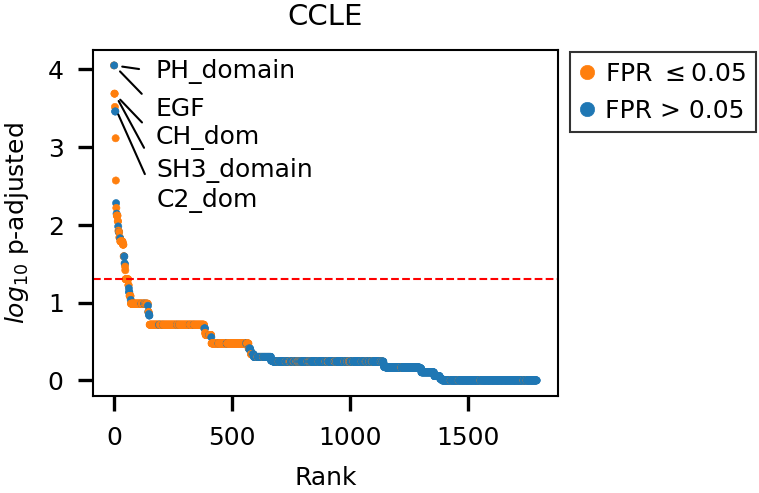

In [14]:
enrich_ccle_novel.plot(catOI = 'True', s = 3, show_fpr = True)
plt.axhline(-1*np.log10(0.05), ls = '--', color = 'r',lw = 0.5)
ax = plt.gca()
EnrichementAnalysis.add_top_ngram_annotations(ax, enrich_ccle_novel.res, proteome_net,
                                              cat='True',
                                              n=5,
                                              yoffset=[-3,-12,-12,-20,-24,-20],
                                              fontsize = 6)
handles,labels = ax.get_legend_handles_labels()
plt.title('CCLE',fontdict={'fontsize':7})
plt.tick_params(labelsize=6)
plt.gcf().set_size_inches(2,1.5)
plt.gcf().set_dpi(300)
plt.legend(handles = handles[::-1], 
           labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],
           loc = 'upper left', 
           bbox_to_anchor = [1,1.03], 
           title = None, 
           handletextpad = 0.5,markerscale = 2,handlelength = 0.5,
           fontsize = 6).get_frame().set_linewidth(0.5)
plt.savefig('Figures/Manuscript/Figure_3/3D_CCLE_Novel_Domain_Enrichment.svg')

Now the TCGA equivalent where we get only the domain architectures per unique fusion protein.

In [15]:
tcga_dansy_res = pd.read_csv('260324_Individual_Fusion_Summary_info.csv', index_col=0,na_values=None)
tcga_dansy_res.dropna(subset=['dansy_impact'], inplace=True)
tcga_dansy_res.domain_architecture.fillna('', inplace=True)

In [16]:
tcga_dansy_minimal = tcga_dansy_res.filter(['name','domain_architecture','dansy_impact']).drop_duplicates()
tcga_dansy_minimal['novel_arch'] = tcga_dansy_minimal.dansy_impact.apply(lambda x: str("Novel" in x))

# Get the n-grams to check for
tcga_ngrams = dansy.ngramUtilities.return_ngrams_from_list(tcga_dansy_minimal.domain_architecture,3)
tcga_ngrams = {k:v for k,v in tcga_ngrams.items() if v > 1}
tcga_ngrams_preexist = sorted(set(tcga_ngrams).intersection(nat_ngrams))

In [17]:
tcga_null_vals = pd.read_csv('260820_Null_p_val_dists_15K_tcga.csv', index_col = 0)

In [21]:
tcga_novel_enrich = EnrichementAnalysis.EnrichmentAnalysis(tcga_dansy_minimal, tcga_ngrams_preexist,
                                                           mapper = {'category':'novel_arch',
                                                                     'domain_architecture':'domain_architecture'},nulldist=tcga_null_vals)

100%|██████████| 5167/5167 [00:15<00:00, 332.50it/s]


In [22]:
# Now perform both of the enrichment analyses based on the two different categories
tcga_dansy_enrich = EnrichementAnalysis.EnrichmentAnalysis(tcga_dansy_minimal, tcga_ngrams_preexist,
                                                           mapper = {'category':'dansy_impact',
                                                                     'domain_architecture':'domain_architecture'})


100%|██████████| 5167/5167 [00:16<00:00, 321.03it/s]


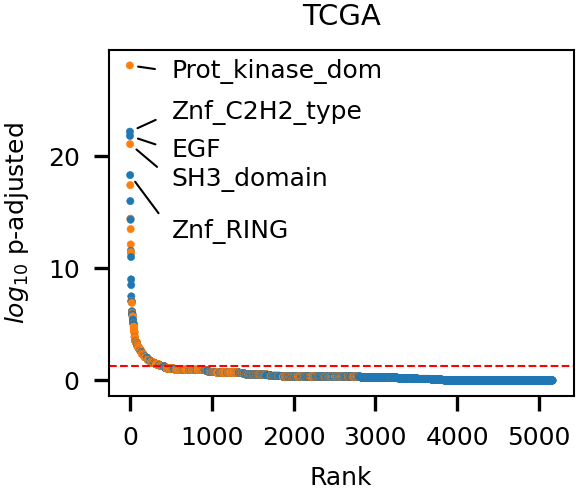

In [23]:
tcga_novel_enrich.plot('True',show_fpr = True, s= 3, legend=False)
ax = plt.gca()
n = min(sum(tcga_novel_enrich.res.True_q.le(0.05)),5)
EnrichementAnalysis.add_top_ngram_annotations(ax, tcga_novel_enrich.res, proteome_net,
                                              cat='True',
                                              n=n,
                                              yoffset=[-3,3,-5,-10,-15],
                                              fontsize = 6)
#handles,labels = ax.get_legend_handles_labels()
plt.axhline(-1*np.log10(0.05), ls = '--', color = 'r', lw = 0.5)
plt.title('TCGA',fontdict={'fontsize':7})
plt.tick_params(labelsize=6)
plt.gcf().set_size_inches(2,1.5)
plt.gcf().set_dpi(300)
#plt.legend(handles = handles[::-1], labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],loc = 'upper left', bbox_to_anchor = [1,1.05], title = None, handletextpad = 0.5,markerscale = 3,handlelength = 0.5).get_frame().set_linewidth(0.5)
plt.savefig('Figures/Manuscript/Figure_3/3D_TCGA_Novel_Domain_Enrichment.svg')

In [24]:
tcga_novel_enrich.res.to_csv('TCGA_Fusion_Domain_Enrichment_Results.csv')

And now for results relative to if the fusion displayed a potential dependence or not

In [22]:
# Importing the dependency scores
dep_res = pd.read_csv('Fusion_dependency_results.csv', index_col = 0)
dep_res = dep_res[~dep_res.duplication]
dep_res.domain_architecture.fillna('',inplace=True)
ccle_dep = dep_res.filter(['fusion_protein', 'dansy_impact','domain_architecture','Lineage','potential_dependence']).drop_duplicates(ignore_index=True)
ccle_dep.potential_dependence = ccle_dep.potential_dependence.astype(str)

In [23]:
ccle_dep_ngrams = dansy.ngramUtilities.return_ngrams_from_list(ccle_dep.domain_architecture,3)
ccle_dep_ngrams = {k:v for k,v in ccle_dep_ngrams.items() if v > 1}
ccle_dep_ngrams = sorted(set(ccle_dep_ngrams).intersection(nat_ngrams))

In [24]:
enrich_ccle_dep = EnrichementAnalysis.EnrichmentAnalysis(ccle_dep, ccle_dep_ngrams,{'category':'potential_dependence','domain_architecture':'domain_architecture'})

100%|██████████| 1061/1061 [00:00<00:00, 1129.06it/s]


In [25]:
enrich_ccle_dep.res

,ngram,True,False,n,True_q,False_q
0,,1.0,1.000000,2143.0,1.0,1.0
1,IPR000001,1.0,0.916976,3.0,1.0,1.0
2,IPR000001|IPR000001,1.0,0.943868,2.0,1.0,1.0
3,IPR000001|IPR000001|IPR001254,1.0,0.943868,2.0,1.0,1.0
4,IPR000001|IPR001254,1.0,0.943868,2.0,1.0,1.0
...,...,...,...,...,...,...
1056,IPR059000,1.0,0.890838,4.0,1.0,1.0
1057,IPR059000|IPR044492,1.0,0.916976,3.0,1.0,1.0
1058,IPR059011,1.0,0.943868,2.0,1.0,1.0
1059,IPR059011|IPR000242,1.0,0.943868,2.0,1.0,1.0


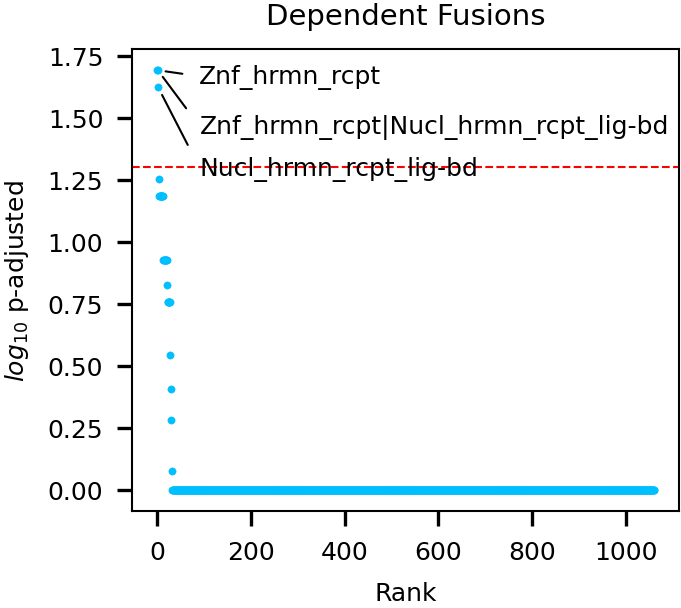

In [26]:
enrich_ccle_dep.plot('True', s = 3)
ax = plt.gca()
n = min(sum(enrich_ccle_dep.res.True_q.le(0.05)),5)
EnrichementAnalysis.add_top_ngram_annotations(ax, enrich_ccle_dep.res, proteome_net,cat='True',n=n,yoffset=[-3,-15,-21,-8,-30,],fontsize = 6)
plt.axhline(-1*np.log10(0.05), ls = '--', color = 'r', lw = 0.5)
plt.title('Dependent Fusions', fontdict={'fontsize':7})
plt.tick_params(labelsize=6)
plt.gcf().set_size_inches(2.35,2)
plt.gcf().set_dpi(300)
plt.savefig('Figures/Manuscript/Supplemental_Figure_13/S13C_Dependency_Domain_enrichment.svg')

Let's compare the TCGA and CCLE results to one another

In [27]:
comp = enrich_ccle_novel.res.filter(['ngram','True_q']).merge(tcga_novel_enrich.res.filter(['ngram','True_q']),on = 'ngram',suffixes=['_CCLE','_TCGA'])
comp['True_q_CCLE_log'] = comp['True_q_CCLE'].apply(lambda x: -1*np.log10(x))
comp['True_q_TCGA_log'] = comp['True_q_TCGA'].apply(lambda x: -1*np.log10(x))

In [29]:
stats.pearsonr(comp.True_q_TCGA_log, comp.True_q_CCLE_log)

PearsonRResult(statistic=0.5744455552886598, pvalue=3.506955993922867e-136)

In [30]:
comp


,ngram,True_q_CCLE,True_q_TCGA,True_q_CCLE_log,True_q_TCGA_log
0,,1.000000,1.000000,-0.000000,-0.000000
1,IPR000001,0.334761,0.131879,0.475266,0.879826
2,IPR000001|IPR000001,0.571822,1.000000,0.242739,-0.000000
3,IPR000001|IPR000001|IPR001254,0.571822,1.000000,0.242739,-0.000000
4,IPR000001|IPR001254,0.571822,1.000000,0.242739,-0.000000
...,...,...,...,...,...
1538,IPR059000,0.571822,0.078690,0.242739,1.104081
1539,IPR059000|IPR044492,0.571822,0.417113,0.242739,0.379746
1540,IPR059011,0.571822,0.392382,0.242739,0.406291
1541,IPR059011|IPR000242,0.571822,1.000000,0.242739,-0.000000


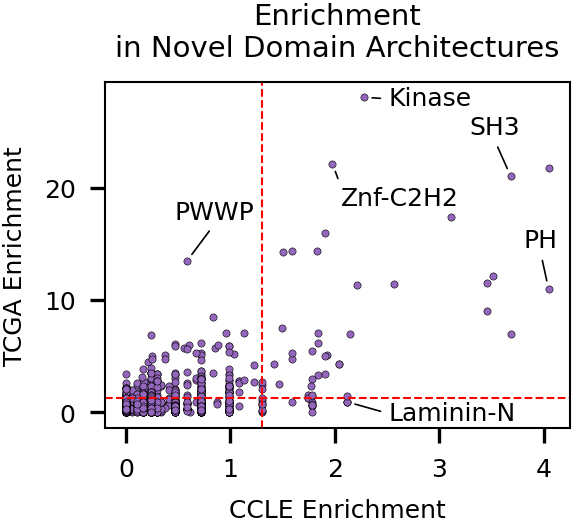

In [81]:
sns.scatterplot(comp, x = 'True_q_CCLE_log', y = 'True_q_TCGA_log', edgecolor = 'k', color = 'tab:purple', s = 3, legend = False)
plt.axhline(-1*np.log10(0.05), ls = '--', color = 'r',lw = 0.5)
plt.axvline(-1*np.log10(0.05), ls = '--', color = 'r', lw =0.5)
plt.ylabel('TCGA Enrichment')
plt.xlabel('CCLE Enrichment')
plt.title('Enrichment\nin Novel Domain Architectures', fontdict={'fontsize':7})
plt.tick_params(labelsize=6)
ax = plt.gca()

for ngram, offset, relpos,label in zip(['IPR000719','IPR001452','IPR001849','IPR013087','IPR008211','IPR000313'],
                                       [(6, -2),(-10, 10),(-6,10),(2,-10),(10,-4.5),(-3,10)],
                                       [(0,0.5),(0.5,0),(0.5,0),(0,1),(0,0.5),(0.5,0)],
                                       ['Kinase','SH3','PH','Znf-C2H2','Laminin-N','PWWP']):
    point = comp[comp['ngram'].eq(ngram)]
    if not point.empty:
        x, y = point[['True_q_CCLE_log', 'True_q_TCGA_log']].iloc[0]
        ax.annotate(
            label,
            (x, y),
            xytext=offset,
            textcoords='offset points',
            fontsize=6,
            arrowprops={'arrowstyle': '-', 'lw': 0.4, 'color': 'k','relpos':relpos},
            bbox = dict(pad=0, facecolor='w', lw=0)
        )
plt.gcf().set_size_inches(2,1.5)
plt.gcf().set_dpi(300)
plt.savefig('Figures/Manuscript/Figure_3/3E_CCLE_TCGA_Enrichment_Comparison.svg')

Getting examples of n-grams that display divergent enrichment between the CCLE and TCGA dataset.

In [32]:
common_enrich_ngrams = set(enrich_ccle_novel.res.ngram).intersection(tcga_novel_enrich.res.ngram)

In [33]:
sig_ccle_ngrams = enrich_ccle_novel.res[enrich_ccle_novel.res['True_q'] < 0.05]['ngram'].tolist()
sig_tcga_ngrams = tcga_novel_enrich.res[tcga_novel_enrich.res['True_q'] < 0.05]['ngram'].tolist()
both_sig_ngrams = set(sig_ccle_ngrams).union(sig_tcga_ngrams)
ccle_diver_candidates = set(sig_ccle_ngrams).difference(sig_tcga_ngrams)
tcga_diver_candidates = set(sig_tcga_ngrams).difference(sig_ccle_ngrams)
common_candids = set(sig_ccle_ngrams).intersection(sig_tcga_ngrams)

In [34]:
tcga_novel_enrich.res[tcga_novel_enrich.res['ngram'].isin(tcga_diver_candidates)].sort_values('True_q')

,ngram,False,True,n,False_q,True_q,fpr,fpr_sig
1131,IPR001841,1.000000,4.936393e-22,232.0,1.0,5.101268e-19,0.21,False
158,IPR000313,1.000000,7.007542e-17,46.0,1.0,3.291634e-14,0.00,True
100,IPR000210,1.000000,1.106215e-11,104.0,1.0,3.175452e-09,0.65,False
1247,IPR001909,1.000000,3.081775e-10,89.0,1.0,7.961764e-08,0.99,False
1739,IPR003598|IPR003598|IPR003598,1.000000,3.959778e-10,106.0,1.0,9.300078e-08,0.08,False
...,...,...,...,...,...,...,...,...
1172,IPR001846|IPR014853,0.999637,3.607167e-03,9.0,1.0,4.904798e-02,0.10,False
68,IPR000095|IPR000719,0.999637,3.607167e-03,9.0,1.0,4.904798e-02,0.00,True
1451,IPR002553,0.999637,3.607167e-03,9.0,1.0,4.904798e-02,0.05,True
1386,IPR002219|IPR000008,0.999637,3.607167e-03,9.0,1.0,4.904798e-02,0.02,True


In [35]:
print(f"There are {len(common_candids)} shared which represents {len(common_candids)/len(common_enrich_ngrams)}% of all n-grams evaluated")
print(f"Of the signficant n-grams the {len(common_candids)} represents {len(both_sig_ngrams)}")

There are 37 shared which represents 0.023979261179520414% of all n-grams evaluated
Of the signficant n-grams the 37 represents 392


In [36]:
len(ccle_diver_candidates)

12

In [37]:
proteome_net.return_legible_ngram('IPR008211')

'Laminin_N'

In [38]:
enrich_ccle_novel.res[enrich_ccle_novel.res['ngram'].isin(ccle_diver_candidates)].sort_values('True_q')

,ngram,False,True,n,False_q,True_q,fpr,fpr_sig
181,IPR000719|IPR015015,1.000000,0.000068,6.0,1.0,0.007641,0.0,True
284,IPR000980|IPR000719|IPR015015,1.000000,0.000068,6.0,1.0,0.007641,0.0,True
978,IPR008211,1.000000,0.000068,6.0,1.0,0.007641,0.0,True
283,IPR000980|IPR000719,0.999980,0.000336,9.0,1.0,0.016392,0.0,True
381,IPR001452|IPR000980|IPR000719,1.000000,0.000339,5.0,1.0,0.016392,0.0,True
496,IPR001791|IPR003585,1.000000,0.000339,5.0,1.0,0.016392,0.0,True
979,IPR008211|IPR002049,1.000000,0.000339,5.0,1.0,0.016392,0.0,True
1010,IPR010507|IPR010507,1.000000,0.000339,5.0,1.0,0.016392,0.0,True
1132,IPR013721,1.000000,0.000339,5.0,1.0,0.016392,0.0,True
37,IPR000195,0.999986,0.000396,7.0,1.0,0.018018,0.0,True


In [39]:
enrich_ccle_novel.res[enrich_ccle_novel.res['ngram'].isin(common_candids)].sort_values('True_q')

,ngram,False,True,n,False_q,True_q,fpr,fpr_sig
185,IPR000742,1.000000,1.002475e-07,83.0,1.0,0.000090,0.12,False
512,IPR001849,1.000000,7.455003e-08,76.0,1.0,0.000090,0.00,True
461,IPR001715,1.000000,4.193520e-07,33.0,1.0,0.000207,0.00,True
377,IPR001452,1.000000,4.623969e-07,71.0,1.0,0.000207,0.02,True
5,IPR000008,1.000000,8.552177e-07,51.0,1.0,0.000306,0.00,True
795,IPR003961,1.000000,1.246286e-06,43.0,1.0,0.000350,0.13,False
124,IPR000504,1.000000,1.370538e-06,49.0,1.0,0.000350,0.07,False
194,IPR000742|IPR000742,0.999999,3.458550e-06,54.0,1.0,0.000774,0.08,False
396,IPR001478,0.999996,1.357973e-05,51.0,1.0,0.002701,0.06,False
175,IPR000719,0.999988,2.946238e-05,115.0,1.0,0.005274,0.33,False


In [40]:
# Now just to show the number of fusion genes and corresponding chimera proteins that are found in both
ccle_fusion_prots = ccle_full_dansy.groupby(['h_uniprot','t_uniprot', 'domain_architecture']).groups.keys()
tcga_fusion_prots = tcga_dansy_res.groupby(['h_uniprot','t_uniprot','domain_architecture']).groups.keys()

# Now they do have some slight difference in the naming convention which is why we are using the uniprot IDs to check them
ovlp = len(set(ccle_fusion_prots).intersection(tcga_fusion_prots))


In [41]:
ovlp

207

In [42]:
len(set(tcga_novel_enrich.ngrams).intersection(enrich_ccle_novel.ngrams))

1543

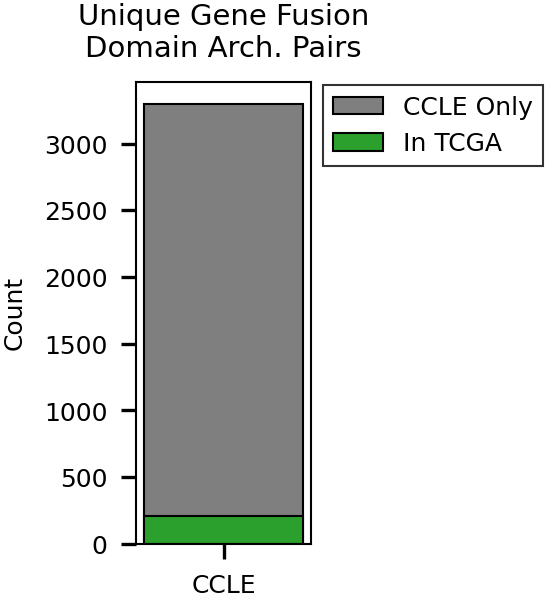

In [43]:
# Creating a somewhat silly but useful barplot to show how many of the CCLE (and also TCGA) fusions overlap
plt.figure(figsize=(0.75,2), dpi =300)
plt.bar(x = 'CCLE', height=len(ccle_fusion_prots), color = 'tab:gray', label = 'CCLE Only', linewidth = 0.5, edgecolor = 'k')
plt.bar(x = 'CCLE', height=ovlp,color = 'tab:green', label='In TCGA',linewidth = 0.5, edgecolor = 'k')
plt.ylabel('Count')
plt.legend(bbox_to_anchor = (1,1.02), fontsize = 6).get_frame().set_linewidth(0.5)
plt.tick_params('both', labelsize = 6)
plt.title('Unique Gene Fusion\nDomain Arch. Pairs', fontdict={'fontsize':7})
plt.savefig('Figures/Manuscript/Supplemental_Figure_13/S13A_CCLE_Fusion_Overlap.svg')

Now let's bring up the betweenness and degree centrality measurements to perform correlations with.

In [44]:
# Because some of the n-grams for the enriched analysis may have to do with collapsed n-grams making a new dansy object to get their values.
uncollapse_proteome = dansy.dansy(ref=ref_df, n=15, collapse = False)

Starting to fetch n-grams.
Finished getting all n-grams
Finished creating edgelist


In [45]:
bcs = nx.betweenness_centrality(uncollapse_proteome.G, k = 3000, seed = 123,normalized=False) # Because of the size of the uncollapsed network, if we try to calculate the betweenness centrality of the entire network it will take quite a bit of time. So we can randomly choose a subset of nodes (in this case 3000) to use as sources for the shortest paths. This gets us a good approximate value that can be used for correlative analyses.
dcs = nx.degree_centrality(uncollapse_proteome.G)

In [46]:
dcs = dict(nx.degree(uncollapse_proteome.G))
dcs[''] = np.nan

In [48]:
reps = {}
dom_insts= {}
for ngram in tcga_novel_enrich.res['ngram'][1:]:
    temp = uncollapse_proteome.retrieve_ngram_protein_info(ngram = ngram)
    reps[ngram] = len(temp)

    # Getting instances of the n-gram
    archs = temp['Interpro Domain Architecture IDs'].tolist()
    instances = [len(re.findall(f"(?={ngram})", i)) for i in archs]
    dom_insts[ngram] = sum(instances)

In [49]:
tcga_res = tcga_novel_enrich.res.copy()
tcga_res['betweenness'] = tcga_res['ngram'].map(bcs)
tcga_res['degree'] = tcga_res['ngram'].map(dcs)
tcga_res['proteins'] = tcga_res['ngram'].map(reps)
tcga_res['instances'] = tcga_res['ngram'].map(dom_insts)

In [50]:
tcga_res.drop(0, inplace=True) # Drop the no domain annotation result

In [51]:
tcga_res['True_q_log'] = tcga_res['True_q'].apply(lambda x: -1*np.log10(x))
tcga_res['betweenness_log'] = tcga_res.betweenness.apply(lambda x: np.log10(x+1))
tcga_res['degree_log'] = tcga_res.degree.apply(lambda x: np.log10(x+1))
tcga_res['proteins_log'] = tcga_res['proteins'].apply(lambda x: np.log10(x))
tcga_res['instances_log'] = tcga_res['instances'].apply(lambda x: np.log10(x))

In [56]:
# All the correlations to show how they are
r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['instances']) # log to make it a positive correlation
print(f"Correlation between the domain instances and enrichment in the TCGA cohort spearman rho:{r:0.3f} with sig: {pv:1.4e}")

r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['proteins']) # log to make it a positive correlation
print(f"Correlation between the protein instances and enrichment in the TCGA cohort spearman rho:{r:0.3f} with sig: {pv:1.4e}")


r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['betweenness']) # log to make it a positive correlation
print(f"Correlation between the betweenness centrality and enrichment in the TCGA cohort spearman rho:{r:0.3f} with sig: {pv:1.4e}")


r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['degree']) # log to make it a positive correlation
print(f"Correlation between the degree centrality and enrichment in the TCGA cohort spearman rho:{r:0.3f} with sig: {pv:1.4e}")

Correlation between the domain instances and enrichment in the TCGA cohort spearman rho:0.191 with sig: 1.3308e-43
Correlation between the protein instances and enrichment in the TCGA cohort spearman rho:0.208 with sig: 1.8323e-51
Correlation between the betweenness centrality and enrichment in the TCGA cohort spearman rho:0.147 with sig: 3.4096e-26
Correlation between the degree centrality and enrichment in the TCGA cohort spearman rho:0.202 with sig: 7.3711e-49


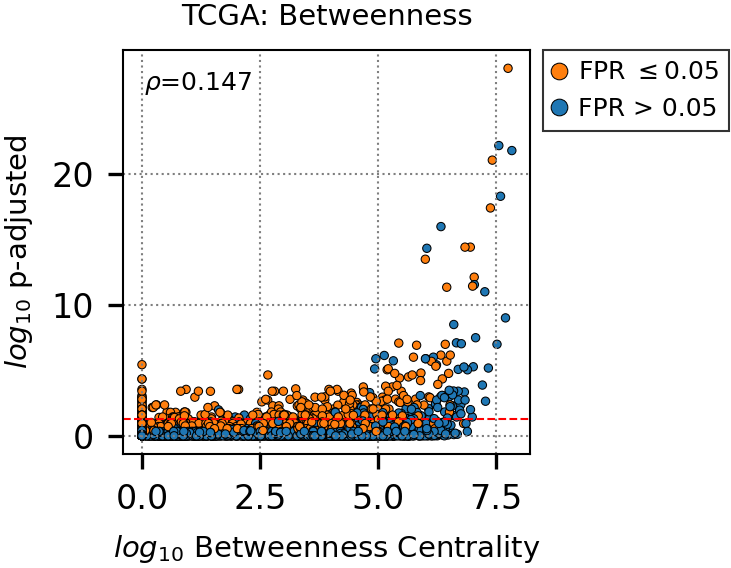

In [52]:
r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['betweenness'])
p = sns.scatterplot(tcga_res, x = 'betweenness_log', y='True_q_log',hue = 'fpr_sig',
                    s = 4,edgecolor = 'k', linewidth = 0.25)
plt.gcf().set_size_inches(1.75,1.75)
plt.gcf().set_dpi(300)
plt.xlabel(r'$log_{10}$ Betweenness Centrality', fontdict = {'fontsize':7})
plt.ylabel(r'$log_{10}$ p-adjusted', fontdict = {'fontsize':7})
plt.axhline(y=-1*np.log10(0.05), ls = '--', color = 'r', lw = 0.5)
plt.title('TCGA: Betweenness', fontdict = {'fontsize':7})
plt.grid('on', color='tab:gray',ls = ':',zorder = 0, lw = 0.5)
handles,_ = p.get_legend_handles_labels()
plt.legend(handles = handles[::-1], 
           labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],
           loc = 'upper left', 
           bbox_to_anchor = [1,1.03], 
           title = None, 
           handletextpad = 0.5,markerscale = 2,handlelength = 0.5,
           fontsize = 6).get_frame().set_linewidth(0.5)

plt.annotate(r"$\rho$="+ f"{r:0.3f}", xy = (0.05, 0.9), xycoords = 'axes fraction', fontsize = 6)

plt.savefig('Figures/Manuscript/Supplemental_Figure_14/S14A_Betweenness.svg')

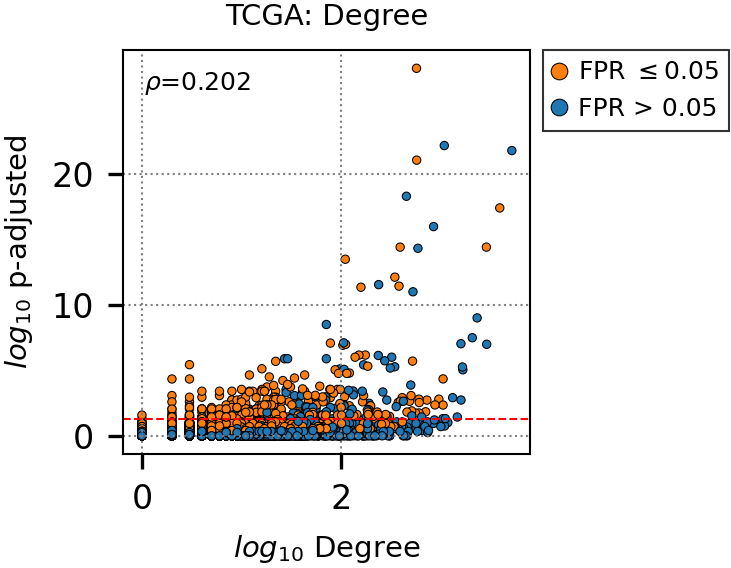

In [53]:
p = sns.scatterplot(tcga_res, x = 'degree_log', y='True_q_log',hue = 'fpr_sig',
                    s = 4,edgecolor = 'k', linewidth = 0.25)
r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['degree'])
plt.gcf().set_size_inches(1.75,1.75)
plt.gcf().set_dpi(300)
plt.xlabel(r'$log_{10}$ Degree', fontdict = {'fontsize':7})
plt.ylabel(r'$log_{10}$ p-adjusted', fontdict = {'fontsize':7})
plt.axhline(y=-1*np.log10(0.05), ls = '--', color = 'r', lw = 0.5)
plt.title('TCGA: Degree', fontdict = {'fontsize':7})
plt.grid('on', color='tab:gray',ls = ':',zorder = 0, lw = 0.5)
handles,_ = p.get_legend_handles_labels()
plt.legend(handles = handles[::-1], 
           labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],
           loc = 'upper left', 
           bbox_to_anchor = [1,1.03], 
           title = None, 
           handletextpad = 0.5,markerscale = 2,handlelength = 0.5,
           fontsize = 6).get_frame().set_linewidth(0.5)

plt.annotate(r"$\rho$="+ f"{r:0.3f}", xy = (0.05, 0.9), xycoords = 'axes fraction', fontsize = 6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_14/S14B_Degree.svg')

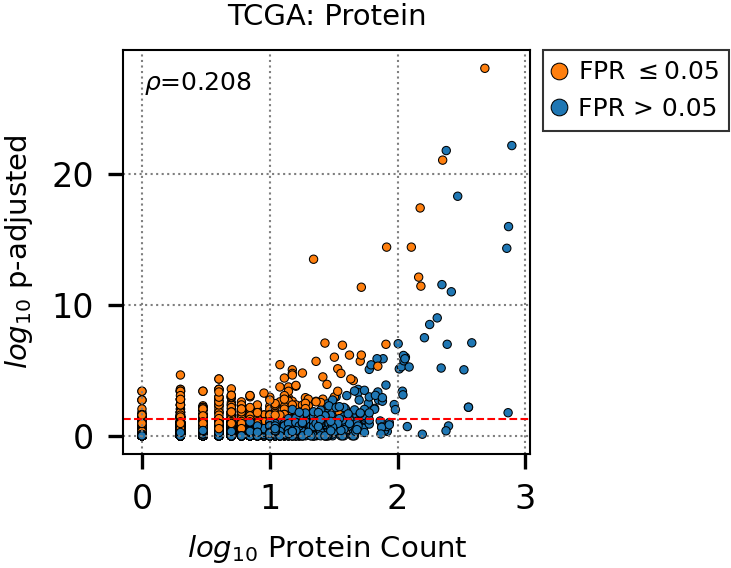

In [54]:
p = sns.scatterplot(tcga_res, x = 'proteins_log', y='True_q_log',hue = 'fpr_sig',
                    s = 4, edgecolor = 'k', linewidth = 0.25)
r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['proteins'])
plt.gcf().set_size_inches(1.75,1.75)
plt.gcf().set_dpi(300)
plt.xlabel(r'$log_{10}$ Protein Count', fontdict = {'fontsize':7})
plt.ylabel(r'$log_{10}$ p-adjusted', fontdict = {'fontsize':7})
plt.axhline(y=-1*np.log10(0.05), ls = '--', color = 'r', lw = 0.5)
plt.title('TCGA: Protein', fontdict = {'fontsize':7})
plt.grid('on', color='tab:gray',ls = ':',zorder = 0, lw = 0.5)
handles,_ = p.get_legend_handles_labels()
plt.legend(handles = handles[::-1], 
           labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],
           loc = 'upper left', 
           bbox_to_anchor = [1,1.03], 
           title = None, 
           handletextpad = 0.5,markerscale = 2,handlelength = 0.5,
           fontsize = 6).get_frame().set_linewidth(0.5)

plt.annotate(r"$\rho$="+ f"{r:0.3f}", xy = (0.05, 0.9), xycoords = 'axes fraction', fontsize = 6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_14/S14C_Proteins.svg')

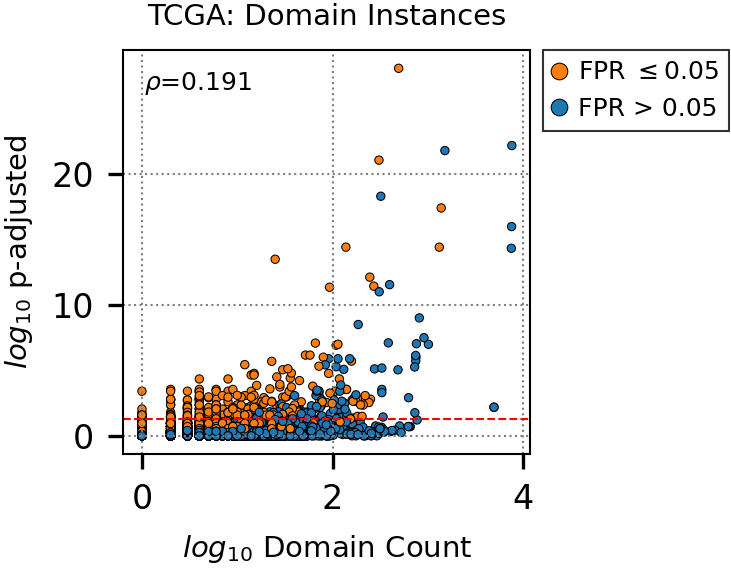

In [69]:
p = sns.scatterplot(tcga_res, x = 'instances_log', y='True_q_log',hue = 'fpr_sig',
                    s = 4, edgecolor = 'k', linewidth = 0.25)
r,pv = stats.spearmanr(tcga_res['True_q_log'], tcga_res['instances'])
plt.gcf().set_size_inches(1.75,1.75)
plt.gcf().set_dpi(300)
plt.xlabel(r'$log_{10}$ Domain Count', fontdict = {'fontsize':7})
plt.ylabel(r'$log_{10}$ p-adjusted', fontdict = {'fontsize':7})
plt.axhline(y=-1*np.log10(0.05), ls = '--', color = 'r', lw = 0.5)
plt.title('TCGA: Domain Instances', fontdict = {'fontsize':7})
plt.grid('on', color='tab:gray',ls = ':',zorder = 0, lw = 0.5)
handles,_ = p.get_legend_handles_labels()
plt.legend(handles = handles[::-1], 
           labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],
           loc = 'upper left', 
           bbox_to_anchor = [1,1.03], 
           title = None, 
           handletextpad = 0.5,markerscale = 2,handlelength = 0.5,
           fontsize = 6).get_frame().set_linewidth(0.5)

plt.annotate(r"$\rho$="+ f"{r:0.3f}", xy = (0.05, 0.9), xycoords = 'axes fraction', fontsize = 6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_14/S14D_Instances.svg')

## Additional Analysis that is not included in the manuscript.

Let's look at recurrent fusions to see if there are patterns of specific domains that occur in the recurrent fusions.

In [59]:
tcga_grouped = tcga_dansy_res.groupby(['name','domain_architecture'])
recurrent_status = pd.Series(index = tcga_grouped.groups, dtype=str)
for group in tcga_grouped.groups:
    x = tcga_grouped.get_group(group)
    recurrent_status.loc[group] = str(len(x['Cancertype'].unique()) > 1)
recurrent_status = recurrent_status.to_frame().reset_index(names=['name','domain_architecture']).rename(columns={0:'Recurrent'})

In [60]:

tcga_recurrent_enrich = EnrichementAnalysis.EnrichmentAnalysis(recurrent_status, tcga_ngrams_preexist, mapper={'domain_architecture':'domain_architecture', 'category':'Recurrent'})

100%|██████████| 5167/5167 [00:15<00:00, 341.05it/s]


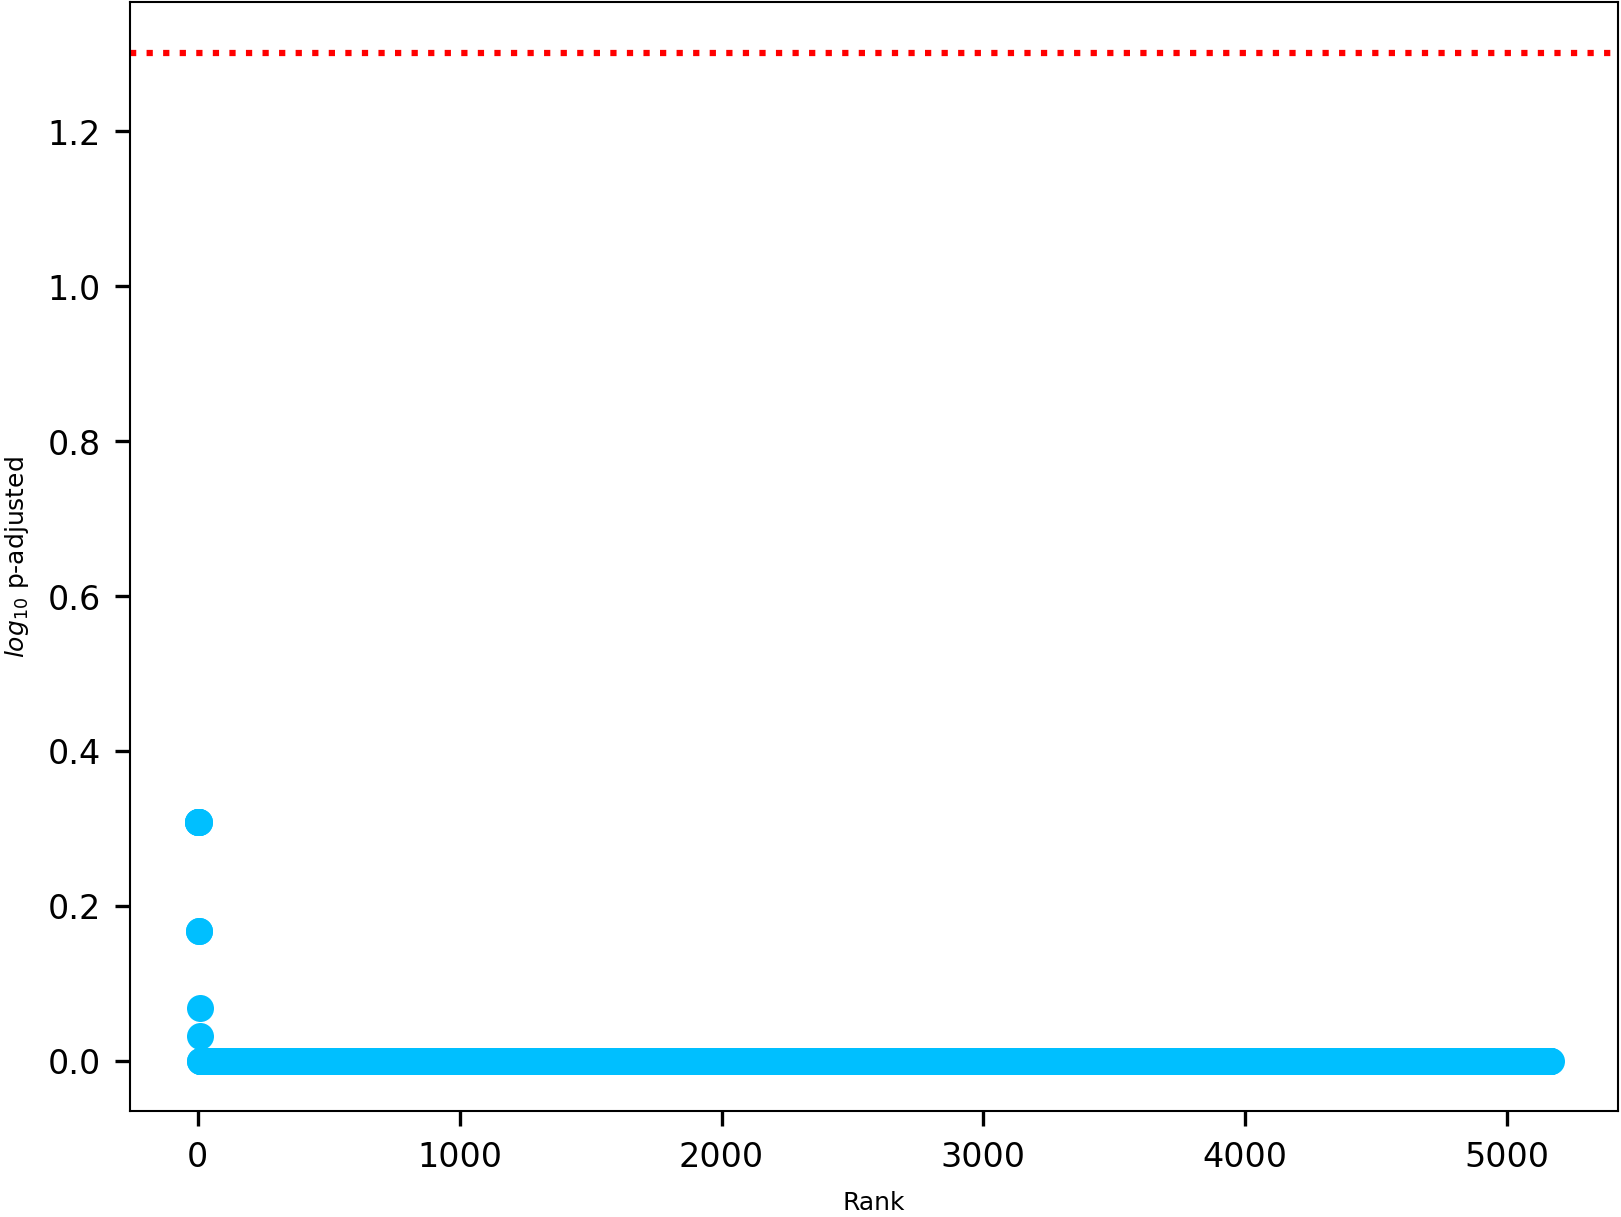

In [61]:
tcga_recurrent_enrich.plot('True', plot_adjusted = True)
ax = plt.gca()
n = min(sum(tcga_recurrent_enrich.res['True_q'].le(0.05)),10)
EnrichementAnalysis.add_top_ngram_annotations(ax, tcga_recurrent_enrich.res[tcga_recurrent_enrich.res['ngram'] != ''], proteome_net,cat='True',n=n,yoffset=[0,8,3,0,12,3,8,0,-8,-15], plot_adjusted=True)
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')

An analysis not included in the manuscript is checking which domains are enriched in those that the chimera protein tend to drop from the original partner genes or something like a domain "de-enrichment" analysis.

In [62]:
# To make it a little easier to find those with dropped domains, I will first grab all the uniprot IDs and get the crontributions overall and compare those to the full length protein.
ids_4_analysis = []
for i,f in ccle_fc.fusion_list.items():
    if 't_contribution' in f.__dict__ and 'h_contribution' in f.__dict__:
        # Now check if there are domain annotations for both parent proteins otherwise won't add
        h_arch = proteome_net.retrieve_protein_info(prot = f.h_uniprot)['Interpro Domain Architecture IDs'].values[0]
        t_arch = proteome_net.retrieve_protein_info(prot = f.t_uniprot)['Interpro Domain Architecture IDs'].values[0]
        if h_arch != '' or t_arch != '': # Ignore the fusions that consist of only proteins with no domain annotations.
            ids_4_analysis.append(i)


In [63]:
deenrich_fusion_dansy = ccle_full_dansy[ccle_full_dansy.id.isin(ids_4_analysis)].copy()

In [64]:
# Now let's append the dropped domains onto the dataframe as another column that can then be unstacked for enrichment analysis
deenrich_fusion_dansy['dropped_domains'] = deenrich_fusion_dansy['id'].apply(lambda x: [ccle_fc.get_fusion(x).h_contribution, ccle_fc.get_fusion(x).t_contribution])
deenrich_fusion_dansy = deenrich_fusion_dansy.explode('dropped_domains')

# Now let's remove the no annotation strings cause they only clutter up the analysis
deenrich_fusion_dansy = deenrich_fusion_dansy[deenrich_fusion_dansy['dropped_domains'] != '']

In [65]:
# Now let's simply the dataframe to be only the most important information and to remove duplicate information that complicates the analysis.
deenrich_data = deenrich_fusion_dansy.filter(['fusion_protein_name', 'dansy_impact', 'dropped_domains']).drop_duplicates()
deenrich_data['novel_arch'] = deenrich_data['dansy_impact'].apply(lambda x: str("Novel" in x))

In [66]:
# Now get only the n-grams in these to focus those within the dropped domains
deenrich_ngrams = dansy.ngramUtilities.return_ngrams_from_list(deenrich_data.dropped_domains,3)

In [67]:
deenrich_dansy_focus = EnrichementAnalysis.EnrichmentAnalysis(deenrich_data, deenrich_ngrams,{'category':'novel_arch','domain_architecture':'dropped_domains'})

100%|██████████| 4205/4205 [00:04<00:00, 947.21it/s]


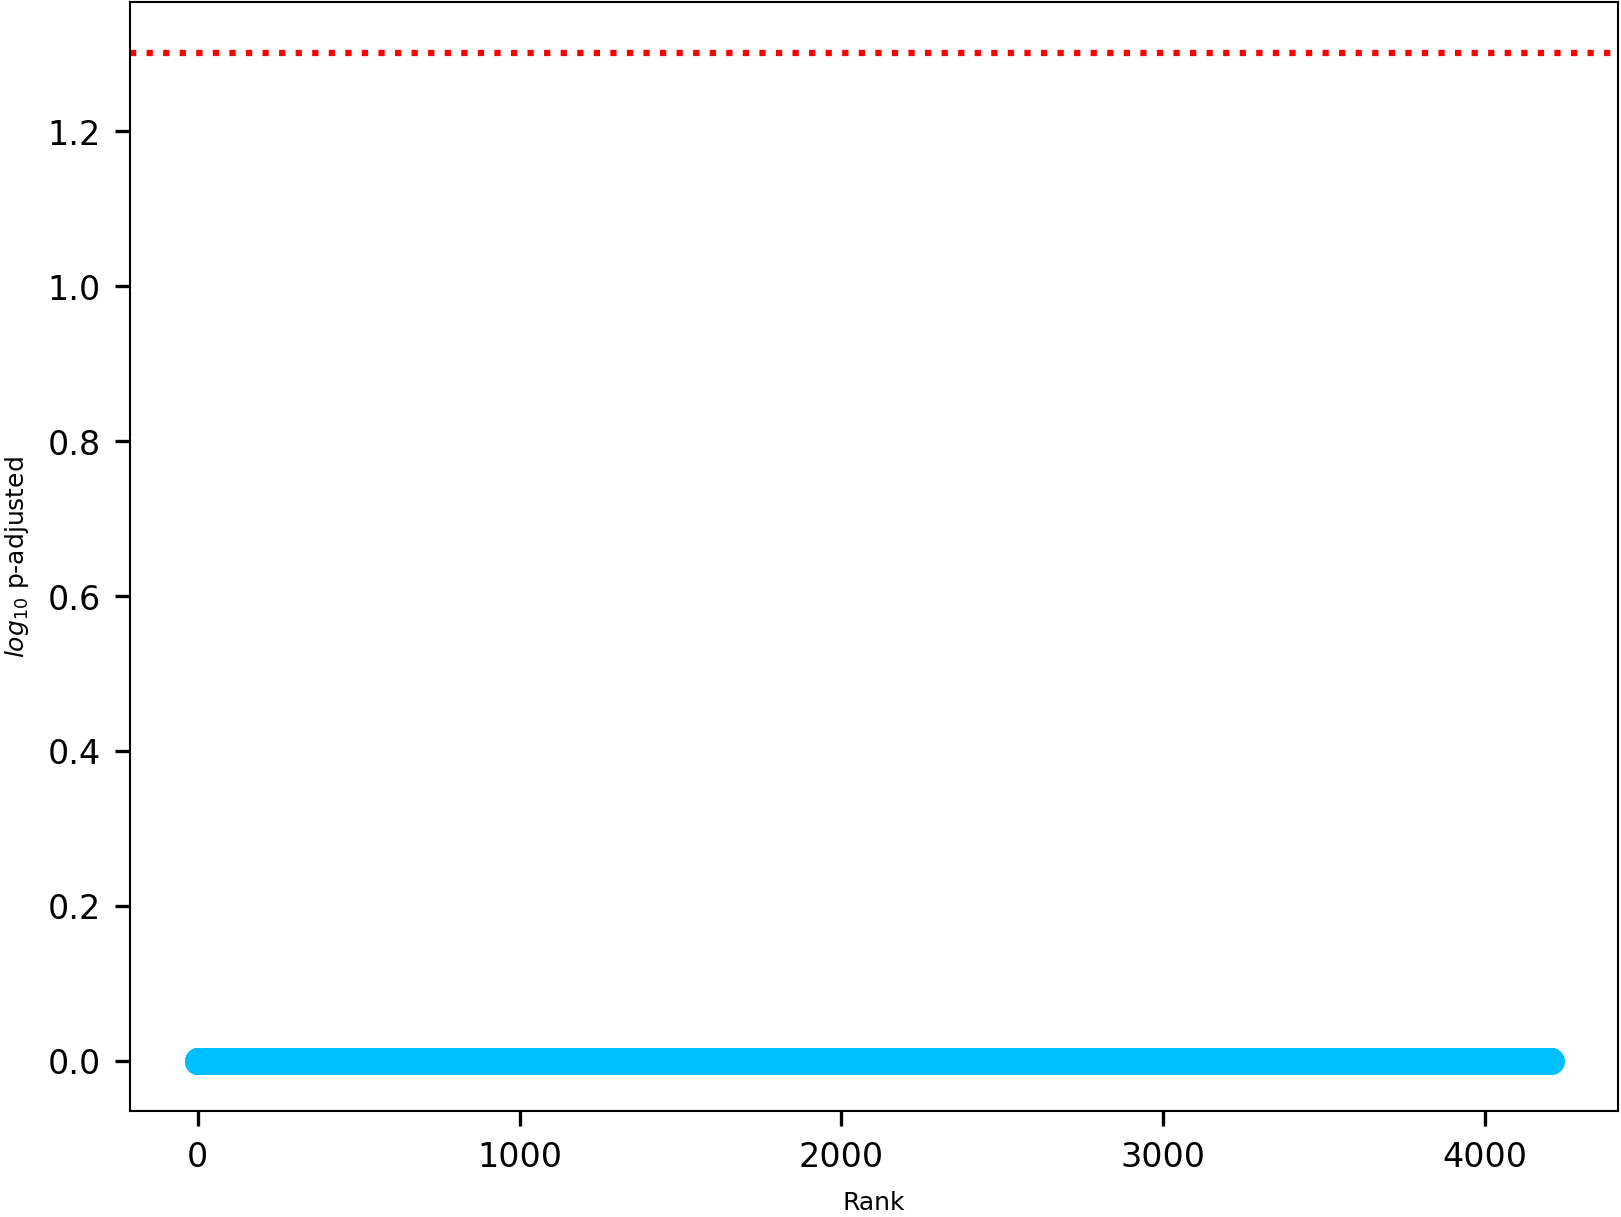

In [68]:
deenrich_dansy_focus.plot('True')
ax = plt.gca()
n = min(sum(deenrich_dansy_focus.res['True_q'].le(0.05)),3)
EnrichementAnalysis.add_top_ngram_annotations(ax, deenrich_dansy_focus.res, proteome_net,cat='True',n=n,yoffset=[0,-8,-15,-5,-12,-8,-12,0,-8,-15], plot_adjusted=True)
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')

Repeating the "de-enrichment" in TCGA instead